<a href="https://colab.research.google.com/github/LetheeshBalaji/24ADI003-24BAD063/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#24BAD063
#Letheesh Balaji
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [33]:
import matplotlib.pyplot as plt
import numpy as np


**Load the Dataset**

In [6]:
df = pd.read_csv("/content/churn_boosting.csv")

In [7]:
df.shape

(120, 5)


**Data
Preprocessing**

In [8]:
df.isnull().sum()

,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,43
Churn,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tenure           120 non-null    int64  
 1   MonthlyCharges   120 non-null    float64
 2   ContractType     120 non-null    object 
 3   InternetService  77 non-null     object 
 4   Churn            120 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ KB


In [10]:
df["InternetService"].unique()

array([nan, 'Fiber optic', 'DSL'], dtype=object)

In [11]:
df["InternetService"].fillna("Unknown", inplace=True)

/tmp/ipykernel_3400/2457176893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["InternetService"].fillna("Unknown", inplace=True)


In [12]:

df["ContractType"].unique()

array(['Two year', 'Month-to-month', 'One year'], dtype=object)

In [14]:
df["Churn"].value_counts()

,count
Churn,
0,113
1,7


In [15]:
df.columns

Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')

In [17]:

le = LabelEncoder()

df["ContractType"] = le.fit_transform(df["ContractType"])
df["InternetService"] = le.fit_transform(df["InternetService"])


In [18]:

X = df.drop(["Churn","InternetService"], axis=1)
y = df["Churn"]

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**
Train AdaBoost Mode**

In [20]:
ada_model = AdaBoostClassifier(n_estimators=20, random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=20, random_state=42)

In [21]:
y_pred_ada = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

In [22]:
print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 1.0


In [23]:


gb_model = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=50, random_state=42)

In [24]:
y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 1.0



**ROC Curve Comparison**

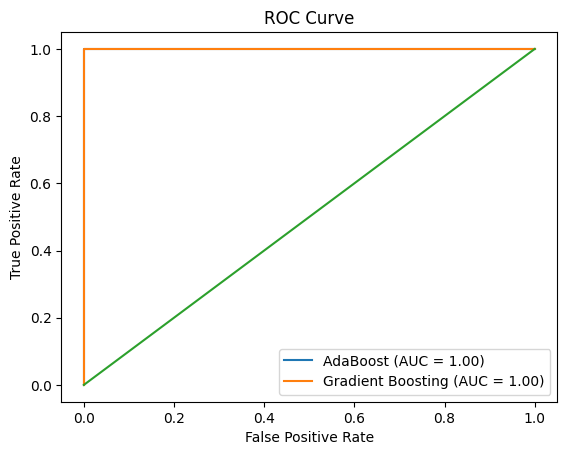

In [27]:
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1])  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [28]:

print(df["ContractType"].value_counts())

ContractType
2    40
0    40
1    40
Name: count, dtype: int64


In [29]:
pd.crosstab(df["ContractType"], df["Churn"])

Churn,0,1
ContractType,,
0,37,3
1,38,2
2,38,2


In [31]:


from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         1

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



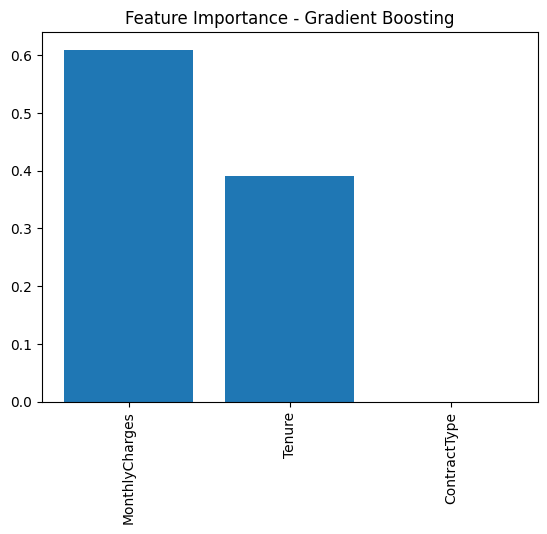

In [34]:


importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance - Gradient Boosting")
plt.show()